KNN accuracy: 0.333
Dummy classifier accuracy: 0.333
Logistic Regression accuracy: 0.500
galaxy_mp(
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=12288, out_features=1024, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=3, bias=True)
)
13116995
old loss 6.290313243865967
new loss: 45.039371490478516


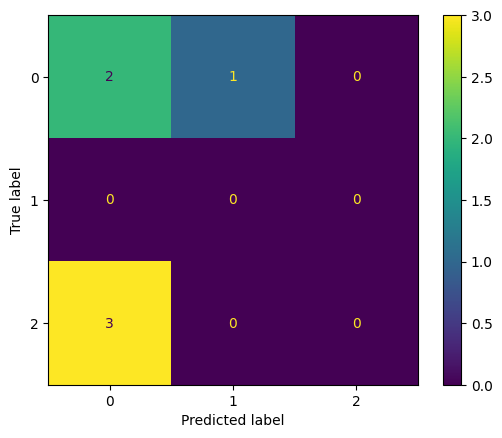

In [ ]:
import pandas as pd
import os
from pathlib import Path
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
# from google.colab import drive
# drive.mount('/content/drive')

RAW_ROOT=Path("/content/drive/MyDrive/raw_ml_astro")
IMAGES_DIR=RAW_ROOT/"images_gz2"
DATA_ROOT=Path("/content/drive/MyDrive/please")

def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None

import shutil

shutil.rmtree(DATA_ROOT, ignore_errors=True)
def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        # print(df["label"].value_counts(dropna=False))

        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
              shutil.copy2(src, dst)
              linked += 1
        counts[label] = linked
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    # print("After merge:", len(df))
    # print(df["gz2_class"].head(20))
    # print(os.listdir(images_dir)[:10])
    # print(os.listdir(IMAGES_DIR)[:20])

    return counts

PER_CLASS = 200
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)

trans=transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor(),transforms.Normalize([0.5]*3,[0.5]*3)])
data=datasets.ImageFolder(root=DATA_ROOT,transform=trans)
image,label=data[0]

trainer=DataLoader(data,batch_size=32,shuffle=False,num_workers=2, pin_memory=True)


# part 1


images_file,label_file=next(iter(trainer))
import numpy as np
im,la=[],[]

for image,label in trainer:
  flat_image=image.flatten(start_dim=1)
  im.append(np.array(flat_image))
  la.append(np.array(label))
images=np.concatenate(im,axis=0)
labels=np.concatenate(la,axis=0)

from sklearn.model_selection import train_test_split
train_im,test_im,train_l,test_l=train_test_split(images,labels,test_size=0.1,random_state=42)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)   # k = 5
knn.fit(train_im, train_l)                    # just memorises the data
pred_l=knn.predict(test_im)
acc = knn.score(test_im, test_l)              # fraction correct on the test set
print(f"KNN accuracy: {acc:.3f}")
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
dum=DummyClassifier(strategy='most_frequent')
dum.fit(train_im,train_l)
per=dum.score(test_im,test_l)
print((f"Dummy classifier accuracy: {acc:.3f}"))

logreg = LogisticRegression(max_iter=1000)   # more iters: high-dim data is slow to converge
logreg.fit(train_im, train_l)
acc = logreg.score(test_im, test_l)
print(f"Logistic Regression accuracy: {acc:.3f}")


## part 2


import torch
import torch.nn as neural_network



class galaxy_mp(neural_network.Module):
  def __init__(self,num_classes=3,in_f=3*64*64,hid=1024,hid2= 512,hid3=16) :
     super().__init__()
     self.flat=neural_network.Flatten()
     self.fc1=neural_network.Linear(in_f,hid)
     self.relu=neural_network.ReLU()
     self.fc2=neural_network.Linear(hid,hid2)
     self.relu=neural_network.ReLU()
     self.fc3=neural_network.Linear(hid2,hid3)
     self.fc4=neural_network.Linear(hid3,num_classes)

  def forward(self,x):
    x=self.flat(x)
    x=self.fc1(x)
    x=self.relu(x)
    x=self.fc2(x)
    return x
  

model=galaxy_mp(num_classes=3)
print(model)
para_count=sum(p.numel() for p in model.parameters())
print(para_count)
# model.train()
logit=model(images_file)

print(logit.shape)


from torch.nn import CrossEntropyLoss as cel


criterion=cel()
loss=criterion(logit,label_file)
print('old loss',loss.item())


from torch.optim import Adam as adam
optimizer=adam(model.parameters(),lr=1e-2) #lr=learning rate
optimizer.zero_grad()
loss.backward()
optimizer.step()

model.train()
logit_new=model(images_file)
loss_new=criterion(logit_new,label_file)
print('new loss:',loss_new.item())# loss depends on learning rate

from sklearn.metrics import confusion_matrix as confu, ConfusionMatrixDisplay as cmd
# con_knn=confu(pred_l,test_l)
cmd.from_predictions(test_l,pred_l)
plt.show()
